# CSE488 — Big Data Analytics
## Term Project: Bangladesh National Election 2026
### Big Data Correlation & Predictive Analytics using Apache Spark

---

**Project Structure**
| Phase | Description |
|---|---|
| Phase 1 | Environment setup & data ingestion |
| Phase 2 | Data engineering & feature construction |
| Phase 3 | Feature engineering & ML pipeline setup |
| Phase 4 | Analytical models (correlation, regression, classification, clustering) |
| Phase 5 | Visualisations & interpretation |

> **Data note:** Upload both CSV files to the Colab session (`Files` panel on the left) before running any cells.
> - `news_scrape_processed.csv`
> - `bangladesh_bbs_population-and-housing-census-dataset_2022_admin-02_-_Merged_All_Table.csv`

---
## Phase 1 — Environment Setup & Data Ingestion

In [1]:
# ─────────────────────────────────────────────────────────────
# 1.0  Install PySpark in the Colab runtime
#      This only needs to run once per session.
# ─────────────────────────────────────────────────────────────
!pip install pyspark --quiet

In [2]:
# ─────────────────────────────────────────────────────────────
# 1.1  Initialise SparkSession
#
#      spark.sql.legacy.timeParserPolicy = LEGACY prevents
#      Spark 3.x from raising errors on some date-format strings.
# ─────────────────────────────────────────────────────────────
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BD_Election_2026") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

# Confirm the session started correctly
print("Spark version:", spark.version)
print("SparkSession active:", spark is not None)

Spark version: 4.0.2
SparkSession active: True


In [3]:
# ─────────────────────────────────────────────────────────────
# 1.2  Load election results (candidate-level)
#
#      Expected shape: 4,035 rows × 11 columns
#      One row per candidate per constituency.
#      Important: 'turnout' stores registered voter count,
#      NOT a percentage — we compute the real % in Phase 2.
# ─────────────────────────────────────────────────────────────
ELEC_PATH = "news_scrape_processed.csv"

elec_raw = spark.read.csv(
    ELEC_PATH,
    header=True,
    inferSchema=True
)

print(f"Rows: {elec_raw.count()}  (expected 4,035)")
print(f"Columns: {len(elec_raw.columns)}  (expected 11)")
print(f"Distinct constituencies: {elec_raw.select('constituency').distinct().count()}  (expected 300)")
elec_raw.printSchema()
elec_raw.show(5, truncate=False)

Rows: 2028  (expected 4,035)
Columns: 10  (expected 11)
Distinct constituencies: 300  (expected 300)
root
 |-- constituency: string (nullable = true)
 |-- candidates: string (nullable = true)
 |-- party: string (nullable = true)
 |-- votes: double (nullable = true)
 |-- turnout: double (nullable = true)
 |-- margin: double (nullable = true)
 |-- referendum_yes: double (nullable = true)
 |-- referendum_no: double (nullable = true)
 |-- male_voter: double (nullable = true)
 |-- female_voter: double (nullable = true)

+------------+------------------------+--------------------------+--------+--------+------+--------------+-------------+----------+------------+
|constituency|candidates              |party                     |votes   |turnout |margin|referendum_yes|referendum_no|male_voter|female_voter|
+------------+------------------------+--------------------------+--------+--------+------+--------------+-------------+----------+------------+
|Bagerhat 1  |Md. Mashirur Rahman Khan|Bangl

In [4]:
# ─────────────────────────────────────────────────────────────
# 1.3  Load BBS / HDX census data (district-level)
#
#      Expected shape: 64 rows × 445 columns
#      One row per district; 445 socio-economic indicators
#      from the Bangladesh Bureau of Statistics 2022 census.
#
#      We cache this DataFrame because it will be joined
#      repeatedly in Phase 2 and referenced in Phase 4.
# ─────────────────────────────────────────────────────────────
HDX_PATH = "/content/bangladesh_bbs_population-and-housing-census-dataset_2022_admin-02 - Merged_All_Table.csv"

hdx_raw = spark.read.csv(
    HDX_PATH,
    header=True,
    inferSchema=True,
    multiLine=True,      # ← handles embedded newlines in cells
    escape='"',          # ← correctly processes quoted fields
    quote='"'
)

hdx_raw.cache()

print(f"Rows: {hdx_raw.count()}  (expected 64)")
print(f"Columns: {len(hdx_raw.columns)}  (expected 445)")

# Confirm no null District keys — if this fails the join in 2D will break
null_districts = hdx_raw.filter(hdx_raw["District"].isNull()).count()
print(f"Null 'District' values: {null_districts}  (expected 0)")

hdx_raw.select("Division", "District").show(64, truncate=False)

Rows: 64  (expected 64)
Columns: 445  (expected 445)
Null 'District' values: 0  (expected 0)
+----------+---------------+
|Division  |District       |
+----------+---------------+
|Barishal  |Barguna        |
|Khulna    |Bagerhat       |
|Barishal  |Barishal       |
|Barishal  |Bhola          |
|Barishal  |Jhalokati      |
|Chattogram|Bandarban      |
|Barishal  |Patuakhali     |
|Barishal  |Pirojpur       |
|Chattogram|Brahmanbaria   |
|Chattogram|Chandpur       |
|Rajshahi  |Bogura         |
|Chattogram|Chattogram     |
|Chattogram|Cumilla        |
|Chattogram|Cox's Bazar    |
|Chattogram|Feni           |
|Chattogram|Khagrachhari   |
|Chattogram|Lakshmipur     |
|Khulna    |Chuadanga      |
|Chattogram|Noakhali       |
|Chattogram|Rangamati      |
|Dhaka     |Dhaka          |
|Dhaka     |Faridpur       |
|Dhaka     |Gazipur        |
|Dhaka     |Gopalganj      |
|Dhaka     |Kishoreganj    |
|Dhaka     |Madaripur      |
|Rangpur   |Dinajpur       |
|Dhaka     |Manikganj      |
|Dhaka  

---
## Phase 2 — Data Engineering

This is the most critical phase. We must transform the 4,035-row candidate-level table into a clean **300-row constituency-level DataFrame** before any modelling can happen. The steps are:

- **2A** — Normalise party names and extract district labels
- **2B** — Aggregate candidates → winners; derive election features
- **2C** — Select and engineer HDX features
- **2D** — Join datasets on `district`
- **2E** — Handle missing values

In [5]:
# ─────────────────────────────────────────────────────────────
# 2A-i  Party name normalisation
#
#      The scraped data contains multiple spelling variants for
#      the same party (e.g., 'BNP' vs 'Bangladesh Nationalist
#      Party (BNP)'). We collapse these to canonical names using
#      a Spark when/otherwise chain so the operation is
#      distributed across executors.
#
#      NOTE: 'Bangladesher Samajtantrik Dal (BSD)' vs '(Marxist)'
#      and 'Jatiya Samajtantrik Dal (JSD)' vs '(JSD Rab)' are
#      NOT merged here — they may be genuine separate factions.
#      Verify against Bangladesh Election Commission records.
# ─────────────────────────────────────────────────────────────
from pyspark.sql.functions import when, col

party_map = {
    "Bangladesh Nationalist Party (BNP)":          "BNP",
    "Islamic Andolon Bangladesh":                   "Islami Andolon Bangladesh",
    "Jatiya Party":                                 "Jatiya Party (JaPa)",
    "Gono Odhikar Parishad":                        "Gono Odhikar Parishad (GOP)",
    "National Citizens Party - NCP":                "NCP",
    "National Citizen Party (NCP)":                 "NCP",
    "Bangladesh Khelafat Majlish":                  "Bangladesh Khilafat Majlis",
    "Bangladesh Islami Front":                      "Bangladesh Islamic Front",
    "Islamic Front Bangladesh":                     "Bangladesh Islamic Front",
    "Insaniyat Biplob Bangladesh":                  "Insaniat Biplob Bangladesh",
    "Insaniat Biplob Bangladesh - Insaniat Biplob": "Insaniat Biplob Bangladesh",
}

# Build the chained when expression
expr = col("party")
for old_name, new_name in party_map.items():
    expr = when(col("party") == old_name, new_name).otherwise(expr)

elec_norm = elec_raw.withColumn("party_clean", expr)

# Verify — confirm mapped names appear and old variants are gone
print("Distinct parties after normalisation:")
elec_norm.select("party_clean").distinct().orderBy("party_clean").show(50, truncate=False)

Distinct parties after normalisation:
+-----------------------------------------------------+
|party_clean                                          |
+-----------------------------------------------------+
|Am Janata Party                                      |
|Amar Bangladesh Party (AB Party)                     |
|BNP                                                  |
|Bangladesh Congress                                  |
|Bangladesh Cultural Liberation Front (Muktijot)      |
|Bangladesh Development Party                         |
|Bangladesh Islamic Front                             |
|Bangladesh Jamaat-e-Islami                           |
|Bangladesh Jatiya Party                              |
|Bangladesh Jatiya Party (BJP)                        |
|Bangladesh Jatiya Samajtantrik Dal (Bangladesh JASAD)|
|Bangladesh Kalyan Party                              |
|Bangladesh Khelafat Andolon                          |
|Bangladesh Khilafat Majlis                           |
|Banglades

In [6]:
# ─────────────────────────────────────────────────────────────
# 2A-ii  Extract district from constituency name
#
#      Constituency names follow the pattern 'District N'
#      (e.g., 'Dhaka 5'). We strip the trailing number to get
#      the district, then apply two known spelling fixes so
#      every election district matches an HDX key exactly.
# ─────────────────────────────────────────────────────────────
import pyspark.sql.functions as F

# Strip trailing whitespace + digits
elec_norm = elec_norm.withColumn(
    "district",
    F.regexp_replace(F.col("constituency"), r"\s+\d+$", "")
)

# Two districts have different spellings between election data and HDX
district_fix = {
    "Jhalokathi": "Jhalokati",
    "Chapainawabganj": "Chapainababganj",
}

dist_expr = col("district")
for old_name, new_name in district_fix.items():
    dist_expr = when(col("district") == old_name, new_name).otherwise(dist_expr)

elec_norm = elec_norm.withColumn("district", dist_expr)

print(f"Distinct districts in election data: {elec_norm.select('district').distinct().count()}  (expected 64)")

Distinct districts in election data: 64  (expected 64)


In [7]:
# New CSV is pre-cleaned — minimal dedup needed.
# Only handle Rangpur 5: drop the duplicate BNP row for Md. Golam Rabbani
# (same candidate scraped under two parties; Jamaat row with higher votes is correct)
from pyspark.sql import Window
import pyspark.sql.functions as F

elec_dedup = elec_norm.withColumn(
    "_rn",
    F.row_number().over(
        Window.partitionBy("constituency", "candidates")
               .orderBy(F.col("votes").desc())   # keeps higher-vote row when name+constituency match
    )
).filter(F.col("_rn") == 1).drop("_rn")

print(f"Rows before dedup: {elec_norm.count()}")
print(f"Rows after dedup:  {elec_dedup.count()}  (expected ~2026)")

const_window = Window.partitionBy("constituency")
elec_agg = elec_dedup.withColumn("total_votes", F.sum("votes").over(const_window))

Rows before dedup: 2028
Rows after dedup:  2026  (expected ~2026)


In [8]:
# ─────────────────────────────────────────────────────────────
# 2B-2  Identify the winner in each constituency
# ─────────────────────────────────────────────────────────────
from pyspark.sql import Window
import pyspark.sql.functions as F

# Step 1: compute total_votes per constituency
elec_agg = elec_agg.withColumn(
    "total_votes",
    F.sum("votes").over(Window.partitionBy("constituency"))
)

# Step 2: compute vote_share_pct  ← ADD THIS BLOCK
elec_agg = elec_agg.withColumn(
    "vote_share_pct",
    (F.col("votes") / F.col("total_votes")) * 100
)

# Step 3: NOW define the tiebreak window (vote_share_pct exists now)
tiebreak_window = Window.partitionBy("constituency").orderBy(
    F.col("votes").desc(),
    F.col("vote_share_pct").desc()
)

elec_ranked = elec_agg.withColumn("row_num", F.row_number().over(tiebreak_window))

winners = elec_ranked.filter(F.col("row_num") == 1).select(
    "constituency", "district", "party_clean",
    "votes", "total_votes", "turnout",
    "male_voter", "female_voter",
    "referendum_yes", "referendum_no",
    "vote_share_pct"
)

winner_count = winners.count()
print(f"Winner rows: {winner_count}  (expected exactly 300)")
assert winner_count == 300, f"Expected 300, got {winner_count} — investigate raw data"

# Flag genuine vote ties
rank_check = elec_agg.withColumn(
    "dense", F.dense_rank().over(
        Window.partitionBy("constituency").orderBy(F.col("votes").desc())
    )
)
genuine_ties = (
    rank_check.filter(F.col("dense") == 1)
    .groupBy("constituency").count()
    .filter("count > 1")
)
tie_count = genuine_ties.count()
if tie_count > 0:
    print(f"\nGenuine vote-tied constituencies ({tie_count}) — verify with EC records:")
    genuine_ties.show(truncate=False)
else:
    print("No genuine vote ties found.")

winners.select("constituency", "party_clean", "votes", "total_votes").show(5, truncate=False)

Winner rows: 300  (expected exactly 300)

Genuine vote-tied constituencies (1) — verify with EC records:
+------------+-----+
|constituency|count|
+------------+-----+
|Sherpur 3   |5    |
+------------+-----+

+------------+--------------------------+--------+-----------+
|constituency|party_clean               |votes   |total_votes|
+------------+--------------------------+--------+-----------+
|Bagerhat 1  |Bangladesh Jamaat-e-Islami|117527.0|244871.0   |
|Bagerhat 2  |Bangladesh Jamaat-e-Islami|117709.0|237396.0   |
|Bagerhat 3  |BNP                       |102661.0|190445.0   |
|Bagerhat 4  |Bangladesh Jamaat-e-Islami|116067.0|224585.0   |
|Bandarban 1 |BNP                       |141455.0|174770.0   |
+------------+--------------------------+--------+-----------+
only showing top 5 rows


In [9]:
# ─────────────────────────────────────────────────────────────
# 2B-3  Derive election-level features
#
#      turnout_pct        — real turnout %: total_votes / registered voters
#                           NOTE: some constituencies show >100% —
#                           data quality anomaly in the scrape. Do NOT
#                           drop; document in your report.
#
#      FIX: use F.nullif(..., F.lit(0)) on all denominators
#      to avoid division-by-zero producing Infinity/NaN.
#
#      Also note: 'turnout' (registered voter count) varies
#      across candidates of the same constituency in the raw
#      data. Now that winners has exactly one row per
#      constituency, this is no longer an issue.
# ─────────────────────────────────────────────────────────────
winners = winners \
    .withColumn(
        "turnout_pct",
        (F.col("total_votes") / F.nullif(F.col("turnout"), F.lit(0)) * 100).cast("double")
    ) \
    .withColumn(
        "gender_ratio",
        (F.col("male_voter") / F.nullif(F.col("female_voter"), F.lit(0))).cast("double")
    ) \
    .withColumn(
        "referendum_approval_pct",
        (F.col("referendum_yes") /
         F.nullif(F.col("referendum_yes") + F.col("referendum_no"), F.lit(0)) * 100).cast("double")
    ) \
    .withColumn(
        "winner_vote_share",
        (F.col("votes") / F.nullif(F.col("total_votes"), F.lit(0)) * 100).cast("double")
    )

# Flag and report anomalous turnout values (document but do not drop)
anomalies = winners.filter(F.col("turnout_pct") > 100)
print(f"Constituencies with turnout_pct > 100%: {anomalies.count()}")
print("(These are data quality anomalies — retained in analysis, documented as limitation)")
anomalies.select("constituency", "total_votes", "turnout", "turnout_pct").show(10, truncate=False)

print("\nSample of derived features (300 rows total):")
winners.select(
    "constituency", "party_clean", "turnout_pct",
    "gender_ratio", "winner_vote_share", "referendum_approval_pct"
).show(5, truncate=False)


Constituencies with turnout_pct > 100%: 1
(These are data quality anomalies — retained in analysis, documented as limitation)
+------------+-----------+--------+------------------+
|constituency|total_votes|turnout |turnout_pct       |
+------------+-----------+--------+------------------+
|Sirajganj 5 |635960.0   |426321.0|149.17397923161187|
+------------+-----------+--------+------------------+


Sample of derived features (300 rows total):
+------------+--------------------------+-----------------+------------------+-----------------+-----------------------+
|constituency|party_clean               |turnout_pct      |gender_ratio      |winner_vote_share|referendum_approval_pct|
+------------+--------------------------+-----------------+------------------+-----------------+-----------------------+
|Bagerhat 1  |Bangladesh Jamaat-e-Islami|65.20156566194483|1.0331203984408834|47.99547516855814|57.67397440160992      |
|Bagerhat 2  |Bangladesh Jamaat-e-Islami|70.23363283226186|0.9851643

In [10]:
# ─────────────────────────────────────────────────────────────
# 2B-4  Compute winning margin
#
#      Margin = winner votes − runner-up votes.
#      FIX: now that winners has exactly 300 rows (one per
#      constituency), the left join with runner_up (also one
#      row per constituency) produces exactly 300 rows.
#
#      We also drop the pre-existing 'margin' column from the
#      raw scrape (unreliable) before computing our own.
# ─────────────────────────────────────────────────────────────

# Runner-up = rank 2 by votes (using row_number for consistency)
runner_up_window = Window.partitionBy("constituency").orderBy(
    F.col("votes").desc(), F.col("vote_share_pct").desc()
)
runner_up = (
    elec_agg
    .withColumn("ru_rank", F.row_number().over(runner_up_window))
    .filter(F.col("ru_rank") == 2)
    .select("constituency", F.col("votes").alias("runner_up_votes"))
)

winners = winners.join(runner_up, on="constituency", how="left") \
    .withColumn("margin", F.col("votes") - F.col("runner_up_votes"))

print(f"Winners after margin join: {winners.count()}  (expected 300)")
null_margins = winners.filter(F.col("margin").isNull()).count()
print(f"Null margins (uncontested seats): {null_margins}")

print("\nMargin sample:")
winners.select("constituency", "votes", "runner_up_votes", "margin") \
       .orderBy(F.col("margin").desc()).show(5, truncate=False)


Winners after margin join: 300  (expected 300)
Null margins (uncontested seats): 1

Margin sample:
+------------+--------+---------------+--------+
|constituency|votes   |runner_up_votes|margin  |
+------------+--------+---------------+--------+
|Sirajganj 5 |588084.0|47876.0        |540208.0|
|Rangamati 1 |201544.0|31222.0        |170322.0|
|Rajbari 2   |237254.0|67299.0        |169955.0|
|Rangpur 5   |175208.0|15115.0        |160093.0|
|Satkhira 2  |266959.0|116293.0       |150666.0|
+------------+--------+---------------+--------+
only showing top 5 rows


In [11]:
# ─────────────────────────────────────────────────────────────
# 2C  Prepare HDX socio-economic features
#
#      We select 15 analytically relevant columns from 445
#      and rename them to short, clean identifiers.
#
#      We then derive:
#        urban_pct          — urban population as % of district total
#        agri/industry/service _share_pct — employment sector shares
# ─────────────────────────────────────────────────────────────
hdx_selected = hdx_raw.select(
    F.col("District").alias("district"),
    F.col("Population Density").alias("pop_density"),
    F.col("Literacy Rate_7year+_Overall").alias("literacy_rate"),
    F.col("%_Inernet_Total_5year+").alias("internet_pct"),
    F.col("%_Mobile Phone_Total_5year+").alias("mobile_pct"),
    F.col("Main Source of Electricity_National Grid_%").alias("electricity_pct"),
    F.col("15-24 Years NEET_%_Overall").alias("neet_pct"),
    F.col("%_Have financial account_Overall").alias("financial_inclusion_pct"),
    F.col("Population Growth Rate, Sex Rat_Overall_Sex_Ratio").alias("sex_ratio"),
    F.col("Employed Population by Sector_Total_Agriculture_#").alias("agri_employed"),
    F.col("Employed Population by Sector_Total_Industry_#").alias("industry_employed"),
    F.col("Employed Population by Sector_Total_Service_#").alias("service_employed"),
    F.col("Household by Structure_Pucca_%").alias("pucca_house_pct"),
    F.col("Population by Sex, Dist & Loca_Population_Urban_Total_#").alias("urban_pop"),
    F.col("Population_Total").alias("total_pop")
)

# Derive urbanisation percentage
hdx_selected = hdx_selected.withColumn(
    "urban_pct",
    (F.col("urban_pop") / F.nullif(F.col("total_pop"), F.lit(0)) * 100).cast("double")
)

# Derive employment sector shares
total_emp = F.col("agri_employed") + F.col("industry_employed") + F.col("service_employed")
safe_total = F.nullif(total_emp, F.lit(0))   # returns NULL if denominator is 0

hdx_selected = hdx_selected \
    .withColumn("agri_share_pct",     (F.col("agri_employed")     / safe_total * 100)) \
    .withColumn("industry_share_pct", (F.col("industry_employed") / safe_total * 100)) \
    .withColumn("service_share_pct",  (F.col("service_employed")  / safe_total * 100))

print("HDX features prepared:")
hdx_selected.printSchema()
hdx_selected.show(5, truncate=False)

HDX features prepared:
root
 |-- district: string (nullable = true)
 |-- pop_density: integer (nullable = true)
 |-- literacy_rate: double (nullable = true)
 |-- internet_pct: double (nullable = true)
 |-- mobile_pct: double (nullable = true)
 |-- electricity_pct: double (nullable = true)
 |-- neet_pct: double (nullable = true)
 |-- financial_inclusion_pct: double (nullable = true)
 |-- sex_ratio: double (nullable = true)
 |-- agri_employed: integer (nullable = true)
 |-- industry_employed: integer (nullable = true)
 |-- service_employed: integer (nullable = true)
 |-- pucca_house_pct: double (nullable = true)
 |-- urban_pop: integer (nullable = true)
 |-- total_pop: integer (nullable = true)
 |-- urban_pct: double (nullable = true)
 |-- agri_share_pct: double (nullable = true)
 |-- industry_share_pct: double (nullable = true)
 |-- service_share_pct: double (nullable = true)

+---------+-----------+-------------+------------+----------+---------------+--------+-----------------------+-

In [12]:
# ─────────────────────────────────────────────────────────────
# 2D  Join election data with HDX socio-economic data
#
#      Left join on 'district'. Every constituency row gets the
#      district-level socio-economic indicators.
#
#      Expected: exactly 300 rows (one per constituency).
#      Limitation: all constituencies within the same district
#      share identical socio-economic values. This reduces
#      within-district variance and weakens model performance.
#      Document this as a limitation in your report.
# ─────────────────────────────────────────────────────────────
master_df = winners.join(hdx_selected, on="district", how="left")

row_count = master_df.count()
print(f"Master DataFrame rows: {row_count}  (expected 300)")
assert row_count == 300, f"Join produced {row_count} rows — check for duplicate district keys in HDX"

# Nulls in literacy_rate → district key mismatch
unmatched = master_df.filter(F.col("literacy_rate").isNull())
print(f"Unmatched constituencies (null literacy_rate): {unmatched.count()}  (expected 0)")

master_df.select(
    "constituency", "district", "party_clean", "turnout_pct",
    "literacy_rate", "internet_pct", "urban_pct"
).show(5, truncate=False)


Master DataFrame rows: 300  (expected 300)
Unmatched constituencies (null literacy_rate): 0  (expected 0)
+------------+---------+--------------------------+-----------------+-------------+------------+-----------------+
|constituency|district |party_clean               |turnout_pct      |literacy_rate|internet_pct|urban_pct        |
+------------+---------+--------------------------+-----------------+-------------+------------+-----------------+
|Bagerhat 1  |Bagerhat |Bangladesh Jamaat-e-Islami|65.20156566194483|81.42        |23.97       |23.87897408429609|
|Bagerhat 2  |Bagerhat |Bangladesh Jamaat-e-Islami|70.23363283226186|81.42        |23.97       |23.87897408429609|
|Bagerhat 3  |Bagerhat |BNP                       |71.36406559146232|81.42        |23.97       |23.87897408429609|
|Bagerhat 4  |Bagerhat |Bangladesh Jamaat-e-Islami|58.99589943233012|81.42        |23.97       |23.87897408429609|
|Bandarban 1 |Bandarban|BNP                       |55.40831013689596|63.74        |23.06 

In [13]:
# ─────────────────────────────────────────────────────────────
# 2E  Handle missing values
#
#      referendum_approval_pct — constituencies where referendum
#        data was not scraped. Impute with global median.
#
#      margin — null for uncontested seats. Impute with 0.
# ─────────────────────────────────────────────────────────────
from pyspark.sql.functions import sum as spark_sum

# Check null counts across key columns
null_counts = master_df.select([
    spark_sum(F.col(c).isNull().cast("int")).alias(c)
    for c in ["referendum_approval_pct", "margin", "turnout_pct",
               "literacy_rate", "internet_pct"]
])
print("Null counts per column (pre-imputation):")
null_counts.show()

# Compute global median for referendum_approval_pct
referendum_median = master_df.approxQuantile("referendum_approval_pct", [0.5], 0.01)[0]
print(f"Referendum approval % global median (imputation value): {referendum_median:.2f}")

master_df = master_df.fillna({
    "referendum_approval_pct": referendum_median,
    "margin": 0.0
})

print("\nNull counts after imputation (expected all 0):")
master_df.select([
    spark_sum(F.col(c).isNull().cast("int")).alias(c)
    for c in ["referendum_approval_pct", "margin"]
]).show()

print(f"\nFinal master_df shape: {master_df.count()} rows × {len(master_df.columns)} columns")


Null counts per column (pre-imputation):
+-----------------------+------+-----------+-------------+------------+
|referendum_approval_pct|margin|turnout_pct|literacy_rate|internet_pct|
+-----------------------+------+-----------+-------------+------------+
|                    110|     1|          1|            0|           0|
+-----------------------+------+-----------+-------------+------------+

Referendum approval % global median (imputation value): 68.10

Null counts after imputation (expected all 0):
+-----------------------+------+
|referendum_approval_pct|margin|
+-----------------------+------+
|                      0|     0|
+-----------------------+------+


Final master_df shape: 300 rows × 35 columns


---
## Phase 3 — Feature Engineering & ML Pipeline Setup

We define class labels for classification, assemble feature vectors, and build reusable Spark ML Pipelines for regression and classification.

In [14]:
# ─────────────────────────────────────────────────────────────
# 3.1  Define classification label
#
#      Parties with ≥5 seats are treated as major classes.
#      All others collapse to 'Other'.
#
#      Expected class distribution (300 constituencies):
#        BNP                        — ~210 seats (70.0%)
#        Bangladesh Jamaat-e-Islami — ~68  seats (22.7%)
#        Independent                — ~8   seats (2.7%)
#        NCP                        — ~6   seats (2.0%)
#        Other                      — ~8   seats (2.7%)
#
#      CLASS IMBALANCE WARNING: BNP ≈ 70%. A naive classifier
#      always predicting BNP achieves ~70% accuracy. Use
#      weighted F1-score as the primary evaluation metric,
#      and inspect per-class precision/recall separately.
# ─────────────────────────────────────────────────────────────
MIN_SEATS = 5

party_counts = winners.groupBy("party_clean").count()
major_parties = [
    r["party_clean"]
    for r in party_counts.filter(F.col("count") >= MIN_SEATS).collect()
]

print("Seat distribution (should sum to 300):")
party_counts.orderBy(F.col("count").desc()).show(20, truncate=False)

master_df = master_df.withColumn(
    "label_party",
    F.when(F.col("party_clean").isin(major_parties), F.col("party_clean")).otherwise("Other")
)

print("\nClass distribution used for classification:")
master_df.groupBy("label_party").count().orderBy(F.col("count").desc()).show()


Seat distribution (should sum to 300):
+-----------------------------------------+-----+
|party_clean                              |count|
+-----------------------------------------+-----+
|BNP                                      |208  |
|Bangladesh Jamaat-e-Islami               |69   |
|Independent                              |8    |
|NCP                                      |6    |
|Bangladesh Khilafat Majlis               |2    |
|Islami Andolon Bangladesh                |2    |
|Gonoshonghoti Andolon                    |1    |
|Bangladesh Jatiya Party (BJP)            |1    |
|Khelafat Majlish                         |1    |
|Gono Odhikar Parishad (GOP)              |1    |
|Revolutionary Workers Party of Bangladesh|1    |
+-----------------------------------------+-----+


Class distribution used for classification:
+--------------------+-----+
|         label_party|count|
+--------------------+-----+
|                 BNP|  208|
|Bangladesh Jamaat...|   69|
|               Othe

In [15]:
# ─────────────────────────────────────────────────────────────
# 3.2 & 3.3  Feature column definitions
#
#      regression_features    — 8 socio-economic predictors of
#                               voter turnout %
#      classification_features — regression_features + 7 extra
#                               columns for party prediction
#
#      VectorAssembler converts the individual numeric columns
#      into a single dense vector required by Spark MLlib.
#
#      MinMaxScaler normalises each feature to [0, 1].
#      This is required for Logistic Regression and ensures
#      correlation analysis is not distorted by scale.
# ─────────────────────────────────────────────────────────────
from pyspark.ml.feature import VectorAssembler, MinMaxScaler, StringIndexer
from pyspark.ml import Pipeline

regression_features = [
    "literacy_rate", "internet_pct", "mobile_pct",
    "urban_pct", "pop_density", "electricity_pct",
    "neet_pct", "financial_inclusion_pct"
]

classification_features = regression_features + [
    "agri_share_pct", "industry_share_pct", "service_share_pct",
    "pucca_house_pct", "sex_ratio", "referendum_approval_pct",
    "gender_ratio"
]

# VectorAssemblers
assembler_reg = VectorAssembler(inputCols=regression_features,      outputCol="features_raw")
assembler_clf = VectorAssembler(inputCols=classification_features,  outputCol="features_raw")

# MinMax scaler
scaler = MinMaxScaler(inputCol="features_raw", outputCol="features")

# StringIndexer maps party name strings to integer labels
label_indexer = StringIndexer(inputCol="label_party", outputCol="label")

# ML Pipelines
pipeline_reg = Pipeline(stages=[assembler_reg, scaler])
pipeline_clf = Pipeline(stages=[assembler_clf, scaler, label_indexer])

print("Regression features:", regression_features)
print("Classification features:", classification_features)
print("\nPipelines defined successfully.")

Regression features: ['literacy_rate', 'internet_pct', 'mobile_pct', 'urban_pct', 'pop_density', 'electricity_pct', 'neet_pct', 'financial_inclusion_pct']
Classification features: ['literacy_rate', 'internet_pct', 'mobile_pct', 'urban_pct', 'pop_density', 'electricity_pct', 'neet_pct', 'financial_inclusion_pct', 'agri_share_pct', 'industry_share_pct', 'service_share_pct', 'pucca_house_pct', 'sex_ratio', 'referendum_approval_pct', 'gender_ratio']

Pipelines defined successfully.


In [16]:
# ─────────────────────────────────────────────────────────────
# 3.4  Train/test split  (80% / 20%)
#
#      seed=42 for reproducibility.
#      With 300 rows the test set is ~60 samples — model
#      evaluation metrics will have high variance. Report
#      this explicitly as a limitation.
# ─────────────────────────────────────────────────────────────
train_df, test_df = master_df.randomSplit([0.8, 0.2], seed=42)

train_df.cache()
test_df.cache()

print(f"Training set: {train_df.count()} rows")
print(f"Test set:     {test_df.count()} rows")
print(f"Total:        {train_df.count() + test_df.count()} rows  (expected ~300)")


Training set: 242 rows
Test set:     58 rows
Total:        300 rows  (expected ~300)


---
## Phase 4 — Analytical Models

### 4.1 Correlation Analysis
### 4.2 Regression Analysis
### 4.3 Classification (Random Forest)
### 4.4 K-Means Clustering

In [17]:
# ─────────────────────────────────────────────────────────────
# 4.1  Correlation Analysis (Section 6.1 requirement)
#
#      Compute Pearson and Spearman correlation between all
#      socio-economic features and voter turnout_pct.
#
#      Hypotheses:
#        literacy_rate        → expected moderate positive (r ≈ 0.4–0.7)
#        internet_pct         → expected weak-moderate positive
#        agri_share_pct       → expected weak negative (rural disengagement)
#        neet_pct             → expected weak negative
# ─────────────────────────────────────────────────────────────
from pyspark.ml.stat import Correlation
import numpy as np

corr_features = regression_features + ["turnout_pct"]

corr_assembler = VectorAssembler(inputCols=corr_features, outputCol="corr_vector")
# Drop any rows with nulls in corr_features before assembling
corr_df = corr_assembler.transform(
    master_df.dropna(subset=corr_features)
).select("corr_vector")

# Compute both matrices
pearson_matrix  = Correlation.corr(corr_df, "corr_vector", method="pearson").collect()[0][0]
spearman_matrix = Correlation.corr(corr_df, "corr_vector", method="spearman").collect()[0][0]

pearson_array  = np.array(pearson_matrix.toArray())
spearman_array = np.array(spearman_matrix.toArray())

# Extract the last row = correlations with turnout_pct
print("Pearson correlations with turnout_pct:")
print("-" * 45)
for feat, val in zip(corr_features[:-1], pearson_array[-1][:-1]):
    print(f"  {feat:<30s} {val:+.4f}")

print("\nSpearman correlations with turnout_pct:")
print("-" * 45)
for feat, val in zip(corr_features[:-1], spearman_array[-1][:-1]):
    print(f"  {feat:<30s} {val:+.4f}")

Pearson correlations with turnout_pct:
---------------------------------------------
  literacy_rate                  -0.1975
  internet_pct                   -0.3897
  mobile_pct                     -0.1813
  urban_pct                      -0.3098
  pop_density                    -0.3148
  electricity_pct                +0.0386
  neet_pct                       +0.0676
  financial_inclusion_pct        +0.0319

Spearman correlations with turnout_pct:
---------------------------------------------
  literacy_rate                  -0.1758
  internet_pct                   -0.3689
  mobile_pct                     -0.0320
  urban_pct                      -0.2455
  pop_density                    -0.2638
  electricity_pct                -0.0023
  neet_pct                       -0.0747
  financial_inclusion_pct        +0.1225


In [18]:
# ─────────────────────────────────────────────────────────────
# 4.2  Linear Regression (Section 6.2 requirement)
#
#      Target: turnout_pct
#      Features: 8 socio-economic predictors (regression_features)
#
#      Expected R² range: 0.2–0.5
#      Low R² is expected and should be discussed as a
#      limitation: all constituencies in the same district share
#      identical HDX values, reducing feature variance.
# ─────────────────────────────────────────────────────────────
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Fit the regression pipeline on training data
# Drop nulls/NaNs in label and features first to prevent SparkRuntimeException
train_df_clean = train_df.dropna(subset=regression_features + ["turnout_pct"])
test_df_clean  = test_df.dropna(subset=regression_features + ["turnout_pct"])

reg_model = pipeline_reg.fit(train_df_clean)
train_reg = reg_model.transform(train_df_clean)
test_reg  = reg_model.transform(test_df_clean)

# Train Linear Regression
lr = LinearRegression(
    featuresCol="features",
    labelCol="turnout_pct",
    maxIter=100
)
lr_model = lr.fit(train_reg)

# Predict on test set
lr_preds = lr_model.transform(test_reg)

# Evaluate
r2_eval   = RegressionEvaluator(labelCol="turnout_pct", metricName="r2")
rmse_eval = RegressionEvaluator(labelCol="turnout_pct", metricName="rmse")

r2   = r2_eval.evaluate(lr_preds)
rmse = rmse_eval.evaluate(lr_preds)

print(f"Linear Regression Results")
print(f"  R²:   {r2:.4f}")
print(f"  RMSE: {rmse:.4f} percentage points")

# Coefficient table — map each coefficient to its feature name
print("\nCoefficients:")
print(f"  {'Feature':<30s} {'Coefficient':>12s}")
print("-" * 44)
for feat, coef in zip(regression_features, lr_model.coefficients):
    print(f"  {feat:<30s} {coef:+12.6f}")
print(f"  {'Intercept':<30s} {lr_model.intercept:+12.6f}")

Linear Regression Results
  R²:   0.2334
  RMSE: 14.0873 percentage points

Coefficients:
  Feature                         Coefficient
--------------------------------------------
  literacy_rate                     -5.841945
  internet_pct                     -22.541984
  mobile_pct                        +6.977014
  urban_pct                         -3.352018
  pop_density                       -7.812683
  electricity_pct                   +9.457833
  neet_pct                          -0.197010
  financial_inclusion_pct          +25.324433
  Intercept                        +46.059877


In [19]:
# ─────────────────────────────────────────────────────────────
# 4.3  Random Forest Classification (Section 6.3 requirement)
#
#      Target: label_party (5 classes)
#      Algorithm: Random Forest (preferred over Logistic
#      Regression because of class imbalance and likely
#      non-linear decision boundaries)
#
#      REMEMBER: BNP holds 70% of seats. Raw accuracy is
#      misleading — use weighted F1-score as the primary metric.
# ─────────────────────────────────────────────────────────────
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Fit the classification pipeline on training data
clf_model = pipeline_clf.fit(train_df)
train_clf = clf_model.transform(train_df)
test_clf  = clf_model.transform(test_df)

# Train Random Forest
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=5,
    seed=42
)
rf_model = rf.fit(train_clf)

# Predict on test set
rf_preds = rf_model.transform(test_clf)

# Evaluate — use weightedF1 as the PRIMARY metric
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy  = evaluator.setMetricName("accuracy").evaluate(rf_preds)
f1        = evaluator.setMetricName("f1").evaluate(rf_preds)
precision = evaluator.setMetricName("weightedPrecision").evaluate(rf_preds)
recall    = evaluator.setMetricName("weightedRecall").evaluate(rf_preds)

print("Random Forest Classification Results")
print(f"  Accuracy:             {accuracy:.4f}")
print(f"  Weighted F1-score:    {f1:.4f}  ← PRIMARY METRIC")
print(f"  Weighted Precision:   {precision:.4f}")
print(f"  Weighted Recall:      {recall:.4f}")

# Feature importance ranking
print("\nFeature Importances (Random Forest):")
importances = rf_model.featureImportances.toArray()
feat_imp = sorted(
    zip(classification_features, importances),
    key=lambda x: x[1], reverse=True
)
for feat, imp in feat_imp:
    print(f"  {feat:<35s} {imp:.4f}")

Random Forest Classification Results
  Accuracy:             0.8276
  Weighted F1-score:    0.7860  ← PRIMARY METRIC
  Weighted Precision:   0.7610
  Weighted Recall:      0.8276

Feature Importances (Random Forest):
  gender_ratio                        0.1261
  pucca_house_pct                     0.1204
  agri_share_pct                      0.0850
  referendum_approval_pct             0.0825
  literacy_rate                       0.0751
  internet_pct                        0.0677
  industry_share_pct                  0.0674
  urban_pct                           0.0671
  sex_ratio                           0.0558
  service_share_pct                   0.0558
  pop_density                         0.0522
  neet_pct                            0.0487
  financial_inclusion_pct             0.0350
  electricity_pct                     0.0337
  mobile_pct                          0.0274


In [20]:
# ─────────────────────────────────────────────────────────────
# 4.3b  Per-class metrics using confusion matrix
#
#      FIX: with only ~300 rows and an 80/20 split, some minority
#      classes may not appear in the training set at all. The
#      fitted StringIndexer then knows fewer integer labels than
#      len(label_to_party), causing a size-mismatch ValueError
#      in classification_report when target_names is passed naively.
#
#      Solution: detect which integer labels actually appear in the
#      test set, build a matching target_names list, and pass both
#      via the `labels` parameter.
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report

# Collect predictions to driver (~60 rows — safe)
pred_pd = rf_preds.select("label", "prediction").toPandas()

# Full label -> party mapping from the fitted StringIndexer (stage index 2)
label_to_party = clf_model.stages[2].labels

# Determine which integer labels actually appear in THIS test set
# Minority parties may be absent if they were only in the training split
present_labels = sorted(pred_pd["label"].astype(int).unique())
present_names  = [label_to_party[i] for i in present_labels]

print("Full label mapping:")
for i, name in enumerate(label_to_party):
    tag = "(in test set)" if i in present_labels else "(absent from test set)"
    print(f"  {i}: {name}  {tag}")
print()

print(classification_report(
    pred_pd["label"].astype(int),
    pred_pd["prediction"].astype(int),
    labels=present_labels,       # only score classes present in y_true
    target_names=present_names,  # matching names
    zero_division=0              # silence warnings for unrepresented classes
))

# Report any absent classes explicitly
absent = [label_to_party[i] for i in range(len(label_to_party)) if i not in present_labels]
if absent:
    print(f"NOTE: {absent} had no test samples and are excluded from the report.")
    print("This is expected given the small dataset (300 rows, ~60 test samples).")


Full label mapping:
  0: BNP  (in test set)
  1: Bangladesh Jamaat-e-Islami  (in test set)
  2: Independent  (in test set)
  3: NCP  (absent from test set)
  4: Other  (in test set)

                            precision    recall  f1-score   support

                       BNP       0.82      0.98      0.89        41
Bangladesh Jamaat-e-Islami       0.89      0.67      0.76        12
               Independent       0.00      0.00      0.00         2
                     Other       0.00      0.00      0.00         3

                  accuracy                           0.83        58
                 macro avg       0.43      0.41      0.41        58
              weighted avg       0.76      0.83      0.79        58

NOTE: ['NCP'] had no test samples and are excluded from the report.
This is expected given the small dataset (300 rows, ~60 test samples).


In [21]:
# ─────────────────────────────────────────────────────────────
# 4.4  K-Means Clustering (Section 6.4 — Recommended)
#
#      Goal: group constituencies into socio-economic clusters
#      and compare their voting patterns.
#
#      We use silhouette score to select optimal k (3–7).
#      A higher silhouette score indicates better-separated
#      clusters (score range: -1 to +1).
# ─────────────────────────────────────────────────────────────
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# We reuse the regression pipeline output for clustering
# (uses the 8 core socio-economic features, already scaled)
master_transformed = pipeline_reg.fit(master_df).transform(master_df)

cluster_evaluator = ClusteringEvaluator(featuresCol="features")

silhouette_scores = {}
for k in range(3, 8):
    kmeans = KMeans(featuresCol="features", k=k, seed=42)
    km_model = kmeans.fit(master_transformed)
    km_preds = km_model.transform(master_transformed)
    score = cluster_evaluator.evaluate(km_preds)
    silhouette_scores[k] = score
    print(f"  k={k}  Silhouette: {score:.4f}")

optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal k = {optimal_k} (highest silhouette)")

  k=3  Silhouette: 0.4697
  k=4  Silhouette: 0.4761
  k=5  Silhouette: 0.5038
  k=6  Silhouette: 0.4669
  k=7  Silhouette: 0.4446

Optimal k = 5 (highest silhouette)


In [22]:
# ─────────────────────────────────────────────────────────────
# 4.4b  Analyse voting patterns per cluster
#
#      After fitting with optimal k, cross-tabulate cluster
#      assignment with winning party.
#
#      FIX: master_transformed does not carry label_party
#      (it was built from pipeline_reg which only uses the
#      8 regression features). We join back via constituency.
# ─────────────────────────────────────────────────────────────
kmeans_final = KMeans(featuresCol="features", k=optimal_k, seed=42)
km_final_model = kmeans_final.fit(master_transformed)
master_clustered = km_final_model.transform(master_transformed)

# Join cluster labels back with party + turnout from master_df
party_lookup = master_df.select("constituency", "label_party", "turnout_pct")
master_clustered = master_clustered \
    .drop("label_party", "turnout_pct") \
    .join(party_lookup, on="constituency", how="left")

print(f"Clustered rows: {master_clustered.count()}  (expected 300)")

print("\nVoting patterns per cluster (party seat counts):")
cluster_analysis = master_clustered.groupBy("prediction", "label_party") \
    .count() \
    .orderBy("prediction", F.col("count").desc())
cluster_analysis.show(50, truncate=False)

print("\nCluster socio-economic profiles (mean values):")
master_clustered.groupBy("prediction").agg(
    F.round(F.mean("literacy_rate"), 2).alias("avg_literacy"),
    F.round(F.mean("internet_pct"),  2).alias("avg_internet"),
    F.round(F.mean("urban_pct"),     2).alias("avg_urban"),
    F.round(F.mean("turnout_pct"),   2).alias("avg_turnout"),
    F.count("*").alias("n_constituencies")
).orderBy("prediction").show()


Clustered rows: 300  (expected 300)

Voting patterns per cluster (party seat counts):
+----------+--------------------------+-----+
|prediction|label_party               |count|
+----------+--------------------------+-----+
|0         |BNP                       |48   |
|0         |Bangladesh Jamaat-e-Islami|18   |
|0         |Independent               |3    |
|0         |Other                     |3    |
|0         |NCP                       |1    |
|1         |BNP                       |13   |
|1         |Bangladesh Jamaat-e-Islami|5    |
|1         |Other                     |1    |
|1         |NCP                       |1    |
|2         |BNP                       |72   |
|2         |Bangladesh Jamaat-e-Islami|37   |
|2         |Independent               |2    |
|2         |Other                     |2    |
|2         |NCP                       |1    |
|3         |BNP                       |26   |
|3         |Bangladesh Jamaat-e-Islami|5    |
|3         |NCP                       |1

---
## Phase 5 — Visualisations & Interpretation

All plots use Matplotlib and Seaborn on data collected from Spark to the driver node. Since we have at most 300 rows, this is safe and efficient.

In [23]:
# ─────────────────────────────────────────────────────────────
# 5.0  Import visualisation libraries
#      Collect master_df once to pandas — reused by all plots.
#      With 300 rows this is safe and fast.
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

master_pd = master_df.toPandas()

print(f"master_pd shape: {master_pd.shape}  (expected 300 rows)")
assert master_pd.shape[0] == 300, f"Expected 300 rows, got {master_pd.shape[0]}"

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120


master_pd shape: (300, 36)  (expected 300 rows)


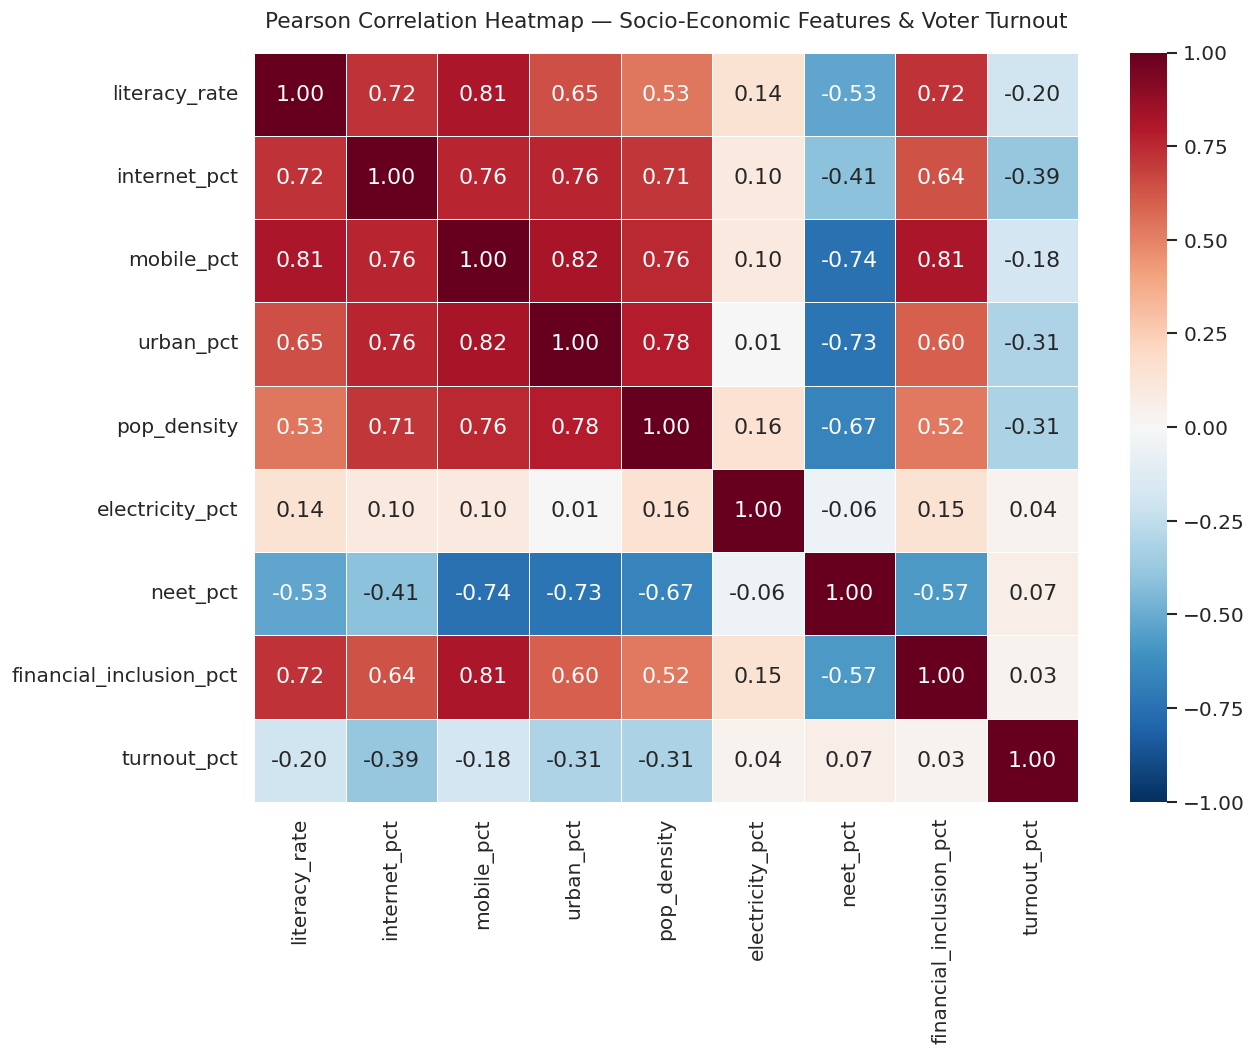

Saved: fig_correlation_heatmap.png


In [24]:
# ─────────────────────────────────────────────────────────────
# 5.1  Pearson Correlation Heatmap
#
#      Shows pairwise correlations between all socio-economic
#      features and turnout_pct. Cells closer to +1 (red) or
#      -1 (blue) indicate stronger relationships.
# ─────────────────────────────────────────────────────────────
corr_cols = regression_features + ["turnout_pct"]
corr_matrix_pd = master_pd[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix_pd,
    annot=True, fmt=".2f",
    cmap="RdBu_r", vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title("Pearson Correlation Heatmap — Socio-Economic Features & Voter Turnout",
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: fig_correlation_heatmap.png")

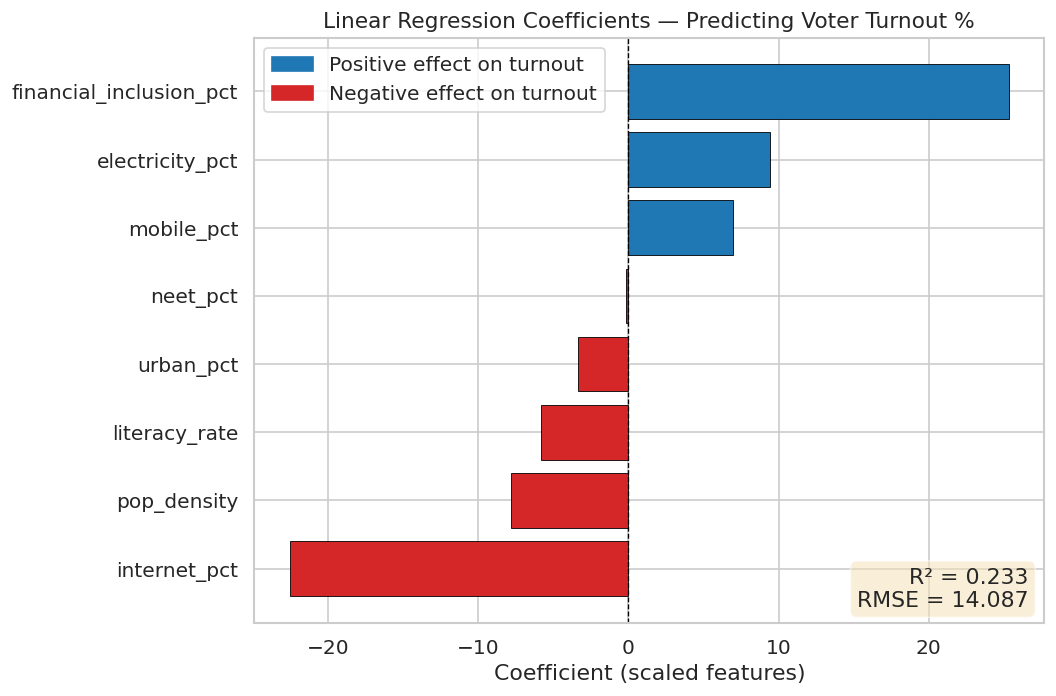

Saved: fig_lr_coefficients.png


In [25]:
# ─────────────────────────────────────────────────────────────
# 5.2  Linear Regression Coefficient Plot
#
#      Bars show the direction and magnitude of each feature's
#      effect on voter turnout %. Positive = increases turnout;
#      negative = decreases turnout (holding others constant).
#
#      Note: coefficients are on scaled [0,1] features, so
#      they are comparable across features.
# ─────────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    "feature": regression_features,
    "coefficient": lr_model.coefficients.toArray()
}).sort_values("coefficient")

colors = ["#d62728" if c < 0 else "#1f77b4" for c in coef_df["coefficient"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coefficient (scaled features)")
ax.set_title("Linear Regression Coefficients — Predicting Voter Turnout %", fontsize=13)

pos_patch = mpatches.Patch(color="#1f77b4", label="Positive effect on turnout")
neg_patch = mpatches.Patch(color="#d62728", label="Negative effect on turnout")
ax.legend(handles=[pos_patch, neg_patch])

# Annotate R² and RMSE
ax.text(0.98, 0.02, f"R² = {r2:.3f}\nRMSE = {rmse:.3f}",
        transform=ax.transAxes, ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("fig_lr_coefficients.png", dpi=150)
plt.show()
print("Saved: fig_lr_coefficients.png")

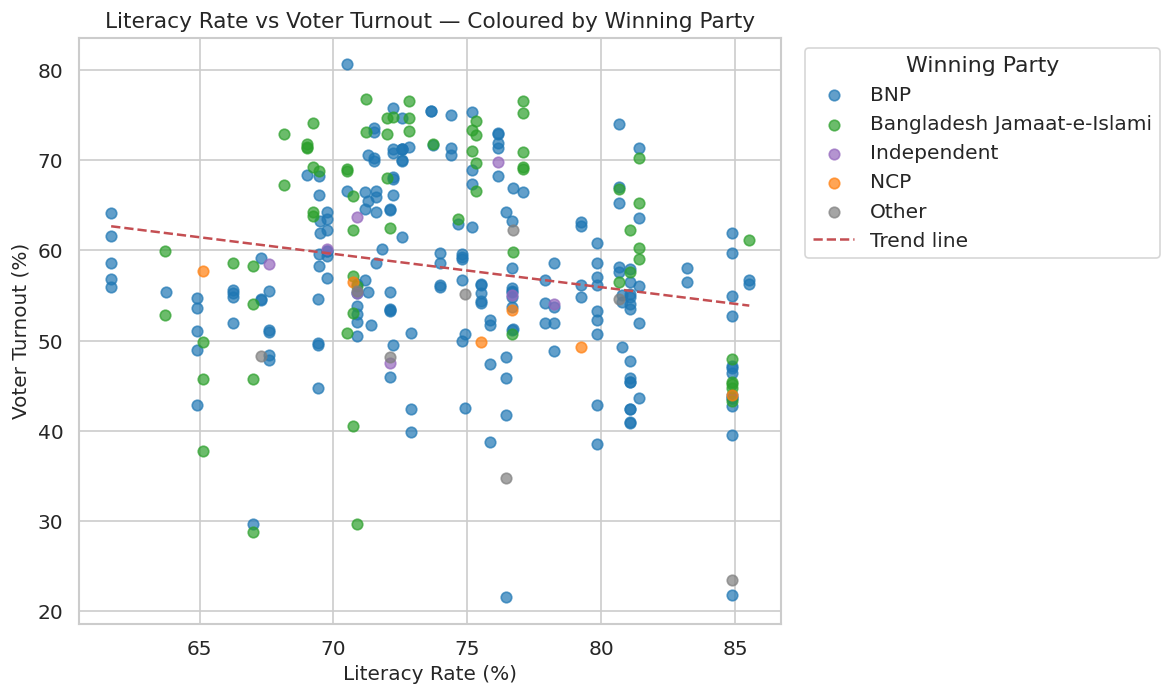

Saved: fig_scatter_literacy_turnout.png


In [26]:
# ─────────────────────────────────────────────────────────────
# 5.3  Scatter: Literacy Rate vs Voter Turnout %
#
#      The core hypothesis: higher-literacy districts have
#      higher voter engagement. Points are coloured by the
#      winning party to reveal any spatial separation.
# ─────────────────────────────────────────────────────────────
# Clip turnout_pct to ≤ 100 for display (anomalies already documented)
plot_df = master_pd[master_pd["turnout_pct"] <= 100].copy()

party_palette = {
    "BNP": "#1f77b4",
    "Bangladesh Jamaat-e-Islami": "#2ca02c",
    "NCP": "#ff7f0e",
    "Independent": "#9467bd",
    "Other": "#7f7f7f"
}

fig, ax = plt.subplots(figsize=(10, 6))
for party, grp in plot_df.groupby("label_party"):
    ax.scatter(
        grp["literacy_rate"], grp["turnout_pct"],
        label=party, alpha=0.7, s=40,
        color=party_palette.get(party, "grey")
    )

# Trend line
m, b = np.polyfit(plot_df["literacy_rate"].dropna(),
                  plot_df.loc[plot_df["literacy_rate"].notna(), "turnout_pct"], 1)
x_range = np.linspace(plot_df["literacy_rate"].min(), plot_df["literacy_rate"].max(), 100)
ax.plot(x_range, m * x_range + b, "r--", linewidth=1.5, label="Trend line")

ax.set_xlabel("Literacy Rate (%)", fontsize=12)
ax.set_ylabel("Voter Turnout (%)", fontsize=12)
ax.set_title("Literacy Rate vs Voter Turnout — Coloured by Winning Party", fontsize=13)
ax.legend(title="Winning Party", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig_scatter_literacy_turnout.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_scatter_literacy_turnout.png")

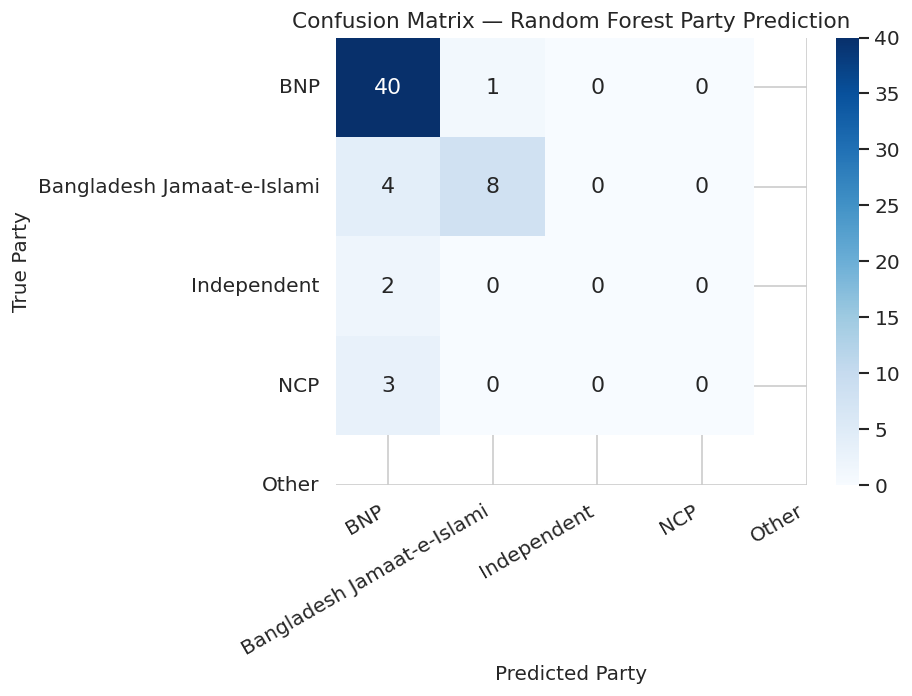

Saved: fig_confusion_matrix.png


In [27]:
# ─────────────────────────────────────────────────────────────
# 5.4  Confusion Matrix — Random Forest Classification
#
#      Rows = true labels, columns = predicted labels.
#      Off-diagonal cells reveal which parties are most
#      frequently confused with each other.
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

y_true = pred_pd["label"].astype(int)
y_pred = pred_pd["prediction"].astype(int)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=label_to_party,
    yticklabels=label_to_party,
    cmap="Blues", ax=ax
)
ax.set_xlabel("Predicted Party", fontsize=12)
ax.set_ylabel("True Party", fontsize=12)
ax.set_title("Confusion Matrix — Random Forest Party Prediction", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: fig_confusion_matrix.png")

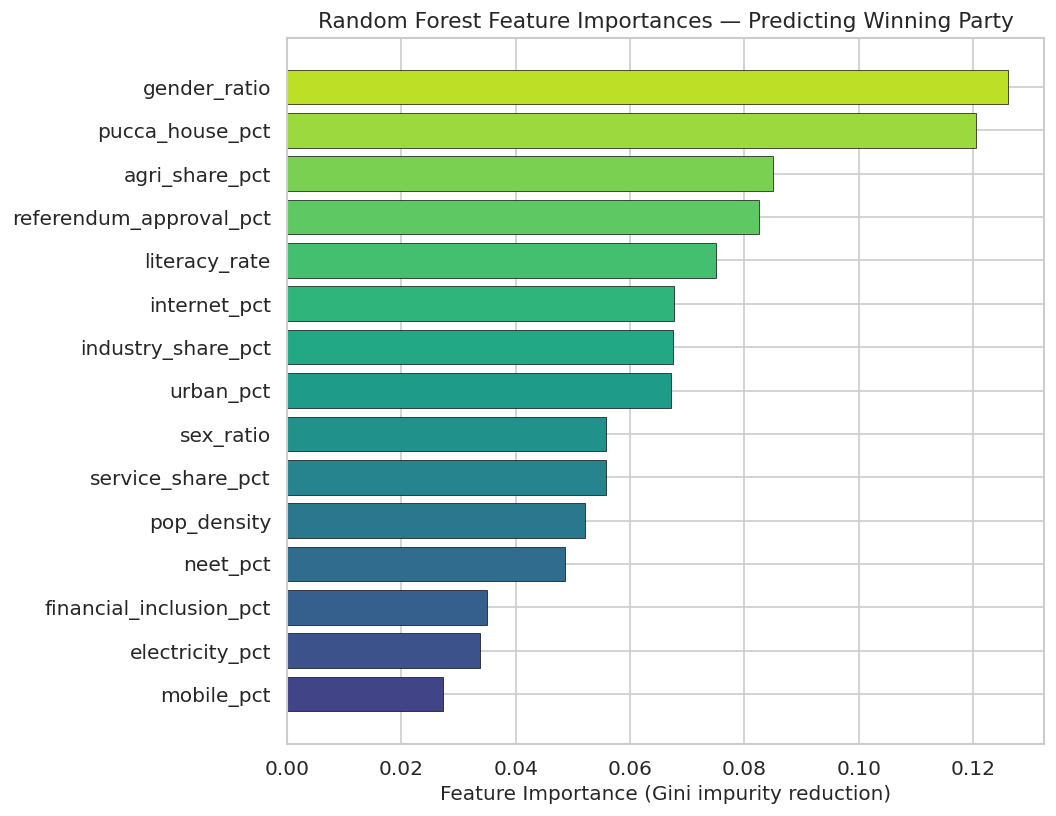

Saved: fig_feature_importance.png


In [28]:
# ─────────────────────────────────────────────────────────────
# 5.5  Feature Importance Bar Chart (Random Forest)
#
#      Shows which socio-economic features the Random Forest
#      relied on most to split decision trees.
#      Higher importance → more predictive of winning party.
# ─────────────────────────────────────────────────────────────
feat_imp_df = pd.DataFrame(feat_imp, columns=["feature", "importance"]).sort_values(
    "importance", ascending=True
)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    feat_imp_df["feature"], feat_imp_df["importance"],
    color=plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp_df))),
    edgecolor="black", linewidth=0.4
)
ax.set_xlabel("Feature Importance (Gini impurity reduction)", fontsize=12)
ax.set_title("Random Forest Feature Importances — Predicting Winning Party", fontsize=13)
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=150)
plt.show()
print("Saved: fig_feature_importance.png")

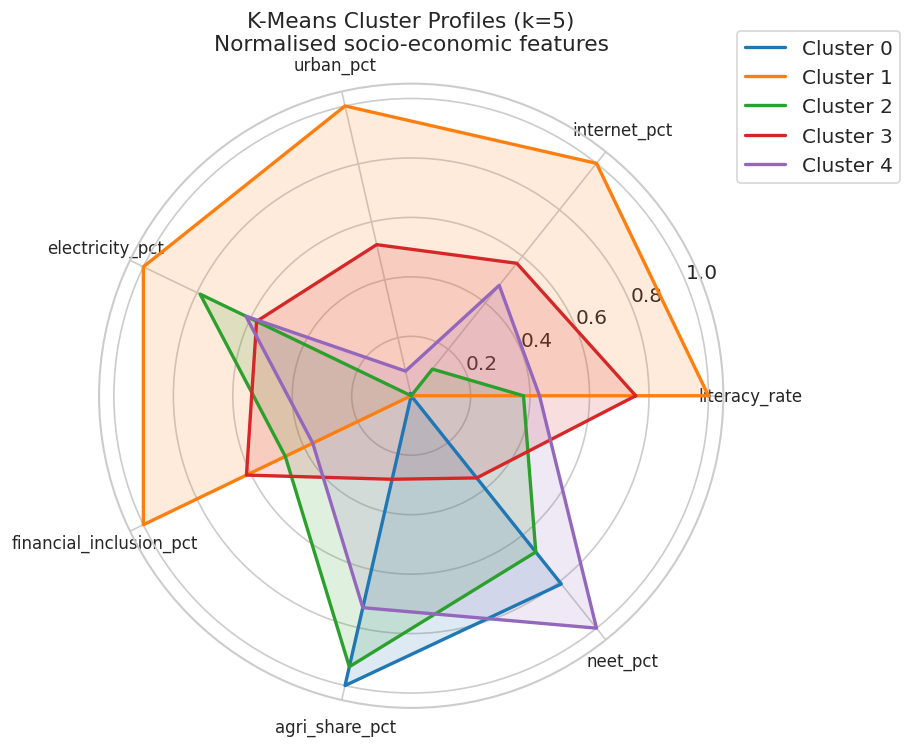

Saved: fig_cluster_radar.png


In [29]:
# ─────────────────────────────────────────────────────────────
# 5.6  Cluster Profile Radar Chart
#
#      Visualises the mean socio-economic profile of each
#      K-Means cluster on a radar (spider) chart.
#      Each axis is a socio-economic feature, normalised to
#      [0, 1] for display purposes.
# ─────────────────────────────────────────────────────────────
# Collect cluster profile to pandas
radar_features = ["literacy_rate", "internet_pct", "urban_pct",
                  "electricity_pct", "financial_inclusion_pct",
                  "agri_share_pct", "neet_pct"]

cluster_profile_pd = master_clustered.groupBy("prediction").agg(
    *[F.mean(f).alias(f) for f in radar_features]
).orderBy("prediction").toPandas()

# Normalise each column to [0, 1] for radar display
for feat in radar_features:
    col_min = cluster_profile_pd[feat].min()
    col_max = cluster_profile_pd[feat].max()
    if col_max > col_min:
        cluster_profile_pd[feat] = (cluster_profile_pd[feat] - col_min) / (col_max - col_min)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"][:optimal_k]

for _, row in cluster_profile_pd.iterrows():
    values = row[radar_features].tolist() + row[radar_features].tolist()[:1]
    cluster_id = int(row["prediction"])
    ax.plot(angles, values, color=colors[cluster_id], linewidth=2, label=f"Cluster {cluster_id}")
    ax.fill(angles, values, color=colors[cluster_id], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title(f"K-Means Cluster Profiles (k={optimal_k})\nNormalised socio-economic features",
             fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("fig_cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_cluster_radar.png")

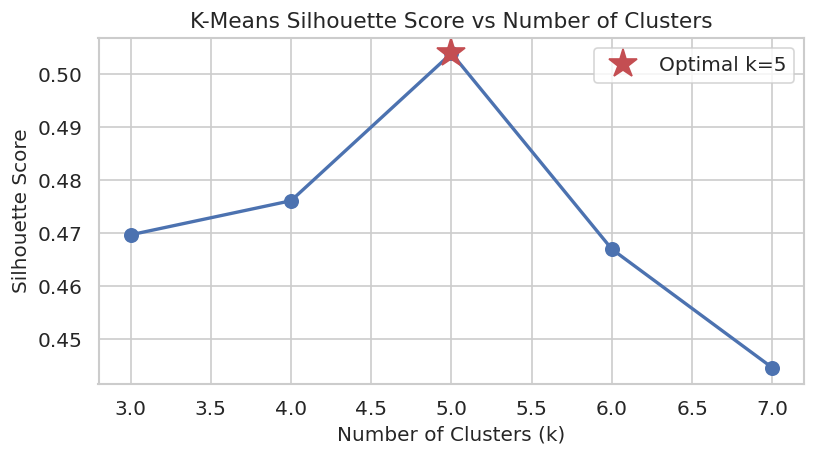

Saved: fig_silhouette_scores.png


In [30]:
# ─────────────────────────────────────────────────────────────
# 5.7  Silhouette Score vs k (Elbow / Selection Plot)
#
#      Shows the silhouette score for each candidate k value.
#      The optimal k is marked with a star.
# ─────────────────────────────────────────────────────────────
k_vals = list(silhouette_scores.keys())
s_vals = list(silhouette_scores.values())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_vals, s_vals, "bo-", linewidth=2, markersize=8)
ax.plot(optimal_k, silhouette_scores[optimal_k], "r*", markersize=18, label=f"Optimal k={optimal_k}")
ax.set_xlabel("Number of Clusters (k)", fontsize=12)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("K-Means Silhouette Score vs Number of Clusters", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("fig_silhouette_scores.png", dpi=150)
plt.show()
print("Saved: fig_silhouette_scores.png")

In [31]:
# ─────────────────────────────────────────────────────────────
# Summary — Key Results
# ─────────────────────────────────────────────────────────────
print("=" * 55)
print("CSE488 — Bangladesh Election 2026: Results Summary")
print("=" * 55)
print()
print("[Correlation Analysis]")
print("  Top correlated features with turnout_pct (Pearson):")
for feat, val in zip(corr_features[:-1], pearson_array[-1][:-1]):
    print(f"    {feat:<35s} r = {val:+.4f}")
print()
print("[Linear Regression — Turnout Prediction]")
print(f"    R²:   {r2:.4f}")
print(f"    RMSE: {rmse:.4f} pp")
print()
print("[Random Forest — Party Classification]")
print(f"    Accuracy:          {accuracy:.4f}")
print(f"    Weighted F1-score: {f1:.4f}  ← PRIMARY METRIC")
print(f"    Weighted Precision:{precision:.4f}")
print(f"    Weighted Recall:   {recall:.4f}")
print()
print("[K-Means Clustering]")
print(f"    Optimal k: {optimal_k}")
for k, s in silhouette_scores.items():
    print(f"    k={k}  Silhouette={s:.4f}" + (" ← optimal" if k == optimal_k else ""))
print()
print("=" * 55)

CSE488 — Bangladesh Election 2026: Results Summary

[Correlation Analysis]
  Top correlated features with turnout_pct (Pearson):
    literacy_rate                       r = -0.1975
    internet_pct                        r = -0.3897
    mobile_pct                          r = -0.1813
    urban_pct                           r = -0.3098
    pop_density                         r = -0.3148
    electricity_pct                     r = +0.0386
    neet_pct                            r = +0.0676
    financial_inclusion_pct             r = +0.0319

[Linear Regression — Turnout Prediction]
    R²:   0.2334
    RMSE: 14.0873 pp

[Random Forest — Party Classification]
    Accuracy:          0.8276
    Weighted F1-score: 0.7860  ← PRIMARY METRIC
    Weighted Precision:0.7610
    Weighted Recall:   0.8276

[K-Means Clustering]
    Optimal k: 5
    k=3  Silhouette=0.4697
    k=4  Silhouette=0.4761
    k=5  Silhouette=0.5038 ← optimal
    k=6  Silhouette=0.4669
    k=7  Silhouette=0.4446



Export to Web Dashboard

In [32]:
from pathlib import Path
import json
import shutil

import pandas as pd
import pyspark.sql.functions as F

# ── 1. Guard: make sure all required variables exist ─────────────────────────
required_vars = [
    "master_df", "elec_ranked", "elec_dedup", "hdx_raw",
    "corr_features", "pearson_array", "spearman_array",
    "lr_model", "r2", "rmse",
    "clf_model", "rf_model", "accuracy", "precision", "recall", "f1",
    "classification_features", "regression_features", "master_clustered"
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError("Run all previous cells first. Missing: " + ", ".join(missing_vars))

# ── 2. Output directory ───────────────────────────────────────────────────────
output_dir = Path("/content/spark_output")
output_dir.mkdir(parents=True, exist_ok=True)

# ── 3. Helpers ────────────────────────────────────────────────────────────────
def write_json(path: Path, payload):
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=True)
        f.write("\n")

def to_float(v, digits=4):
    return round(float(v), digits) if v is not None else 0.0

# ── 4. HDX export ─────────────────────────────────────────────────────────────
hdx_cols = set(hdx_raw.columns)

def hdx_number(candidates, alias):
    for c in candidates:
        if c in hdx_cols:
            return F.col(c).cast("double").alias(alias)
    return F.lit(None).cast("double").alias(alias)

def hdx_text(candidates, alias):
    for c in candidates:
        if c in hdx_cols:
            return F.col(c).cast("string").alias(alias)
    return F.lit(None).cast("string").alias(alias)

hdx_export = (
    hdx_raw.select(
        F.col("District").alias("district"),
        hdx_text(["Division"], "division"),
        hdx_number(["Population_Total", "total_pop"], "Population_Total"),
        hdx_number(["Household_Total"], "Household_Total"),
        hdx_number(["Population_Total", "total_pop"], "pop_total_loc"),
        hdx_number(["Population by Sex, Dist & Loca_Population_Rural_Total_#", "pop_rural"], "pop_rural"),
        hdx_number(["Population by Sex, Dist & Loca_Population_Urban_Total_#", "urban_pop", "pop_urban"], "pop_urban"),
        hdx_number(["Population by Sex, Dist & Loca_Population_Total_Male_#", "pop_male"], "pop_male"),
        hdx_number(["Population by Sex, Dist & Loca_Population_Total_Female_#", "pop_female"], "pop_female"),
        hdx_number(["Literacy Rate_7year+_Male", "literacy_male"], "literacy_male"),
        hdx_number(["Literacy Rate_7year+_Female", "literacy_female"], "literacy_female"),
        hdx_number(["%_Inernet_Male_5year+", "internet_male_pct"], "internet_male_pct"),
        hdx_number(["%_Inernet_Female_5year+", "internet_female_pct"], "internet_female_pct"),
        hdx_number(["%_Mobile Phone_Total_5year+", "mobile_phone_pct"], "mobile_phone_pct"),
        hdx_number(["Dependency Ratio_Overall", "dependency_ratio"], "dependency_ratio"),
        hdx_number(["Population by Religion_Islam_#", "pop_muslim"], "pop_muslim"),
        hdx_number(["Population by Religion_Hindu_#", "pop_hindu"], "pop_hindu"),
        hdx_number(["Looking for Work_Total", "looking_for_work"], "looking_for_work")
    )
    .dropDuplicates(["district"])
)

# ── 5. Election detail tables ─────────────────────────────────────────────────
winner_detail = (
    elec_ranked.filter(F.col("row_num") == 1)
    .select(
        "constituency",
        F.col("candidates").alias("winner_candidate"),
        F.col("party_clean").alias("winner_party"),
        F.col("votes").cast("double").alias("winner_votes"),
        F.col("total_votes").cast("double").alias("total_valid_votes"),
        F.col("vote_share_pct").cast("double").alias("winner_vote_share_pct")
    )
)

runner_detail = (
    elec_ranked.filter(F.col("row_num") == 2)
    .select(
        "constituency",
        F.col("candidates").alias("runner_up_candidate"),
        F.col("party_clean").alias("runner_up_party"),
        F.col("votes").cast("double").alias("runner_up_votes_calc")
    )
)

candidate_counts = (
    elec_dedup
    .groupBy("constituency")
    .agg(F.count("*").cast("int").alias("candidate_count"))
)

# ── 6. Join into analytics dataframe ─────────────────────────────────────────
analytics_df = (
    master_df
    .join(winner_detail,     on="constituency", how="left")
    .join(runner_detail,     on="constituency", how="left")
    .join(candidate_counts,  on="constituency", how="left")
    .join(hdx_export,        on="district",     how="left")
)

if "party_clean" not in analytics_df.columns:
    analytics_df = analytics_df.withColumn("party_clean", F.lit(""))

# Ensure expected numeric source columns exist
source_number_defaults = [
    "votes", "total_votes", "runner_up_votes", "winner_vote_share", "margin",
    "pop_density", "literacy_rate", "internet_pct", "mobile_pct", "neet_pct",
    "financial_inclusion_pct", "sex_ratio", "agri_employed", "industry_employed",
    "service_employed", "urban_pct"
]
for c in source_number_defaults:
    if c not in analytics_df.columns:
        analytics_df = analytics_df.withColumn(c, F.lit(None).cast("double"))

# ── 7. Derived columns ────────────────────────────────────────────────────────
winner_party_lower = F.lower(
    F.coalesce(F.col("winner_party"), F.col("party_clean"), F.lit(""))
)

analytics_df = (
    analytics_df
    .withColumn("winner_party",          F.coalesce(F.col("winner_party"), F.col("party_clean")))
    .withColumn("winner_votes",          F.coalesce(F.col("winner_votes"), F.col("votes").cast("double")))
    .withColumn("runner_up_votes",       F.coalesce(F.col("runner_up_votes").cast("double"), F.col("runner_up_votes_calc")))
    .withColumn("total_valid_votes",     F.coalesce(F.col("total_valid_votes"), F.col("total_votes").cast("double")))
    .withColumn("winner_vote_share_pct", F.coalesce(F.col("winner_vote_share_pct"), F.col("winner_vote_share").cast("double")))
    .withColumn("winning_margin_votes",  F.coalesce(F.col("margin").cast("double"), F.col("winner_votes") - F.col("runner_up_votes")))
    .withColumn("winning_margin_pct",
        F.when(F.col("total_valid_votes") > 0,
               (F.col("winning_margin_votes") / F.col("total_valid_votes")) * 100))
    .withColumn("alliance",
        F.when(winner_party_lower.contains("jamaat"), F.lit("jamaat"))
         .when((winner_party_lower == "bnp") | winner_party_lower.contains("nationalist"), F.lit("bnp"))
         .otherwise(F.lit("others")))
    .withColumn("Population_Total",      F.col("Population_Total").cast("double"))
    .withColumn("pop_total_loc",         F.coalesce(F.col("pop_total_loc"), F.col("Population_Total")))
    .withColumn("mobile_phone_pct",      F.coalesce(F.col("mobile_phone_pct"), F.col("mobile_pct").cast("double")))
    .withColumn("financial_account_pct", F.col("financial_inclusion_pct").cast("double"))
    .withColumn("employed_total",
        F.coalesce(F.col("agri_employed"),      F.lit(0.0)) +
        F.coalesce(F.col("industry_employed"),  F.lit(0.0)) +
        F.coalesce(F.col("service_employed"),   F.lit(0.0)))
    .withColumn("urbanization_index",
        F.coalesce(
            F.col("urban_pct").cast("double"),
            F.when(F.col("Population_Total") > 0,
                   (F.col("pop_urban") / F.col("Population_Total")) * 100)))
    .withColumn("employment_rate_pct",
        F.when(F.col("Population_Total") > 0,
               (F.col("employed_total") / F.col("Population_Total")) * 100))
    .withColumn("muslim_majority_pct",
        F.when((F.col("Population_Total") > 0) & F.col("pop_muslim").isNotNull(),
               (F.col("pop_muslim") / F.col("Population_Total")) * 100))
    .withColumn("hindu_pct",
        F.when((F.col("Population_Total") > 0) & F.col("pop_hindu").isNotNull(),
               (F.col("pop_hindu") / F.col("Population_Total")) * 100))
    .withColumn("female_pct",
        F.when((F.col("Population_Total") > 0) & F.col("pop_female").isNotNull(),
               (F.col("pop_female") / F.col("Population_Total")) * 100))
    .withColumn("competitiveness_index",
        F.when(F.col("winning_margin_pct").isNotNull(),
               100.0 / (F.col("winning_margin_pct") + F.lit(1.0))))
    .withColumn("turnout_pct", F.col("turnout_pct").cast("double"))
    .withColumn("division",    F.coalesce(F.col("division"), F.lit("Unknown")))
)

# ── 8. Final column selection & type casting ──────────────────────────────────
string_columns = [
    "constituency", "district", "division", "alliance",
    "winner_candidate", "winner_party", "runner_up_candidate", "runner_up_party"
]
int_columns = [
    "winner_votes", "runner_up_votes", "total_valid_votes", "candidate_count",
    "Population_Total", "Household_Total", "pop_total_loc", "pop_rural", "pop_urban",
    "pop_male", "pop_female", "employed_total", "looking_for_work", "pop_muslim", "pop_hindu"
]
float_columns = [
    "pop_density", "literacy_rate", "literacy_male", "literacy_female",
    "internet_pct", "internet_male_pct", "internet_female_pct", "mobile_phone_pct",
    "neet_pct", "financial_account_pct", "sex_ratio", "dependency_ratio",
    "turnout_pct", "winning_margin_pct", "winner_vote_share_pct",
    "urbanization_index", "employment_rate_pct", "competitiveness_index",
    "muslim_majority_pct", "hindu_pct", "female_pct"
]

for c in string_columns:
    if c not in analytics_df.columns:
        analytics_df = analytics_df.withColumn(c, F.lit(""))

for c in int_columns:
    if c not in analytics_df.columns:
        analytics_df = analytics_df.withColumn(c, F.lit(None).cast("int"))
    else:
        analytics_df = analytics_df.withColumn(c, F.col(c).cast("int"))

for c in float_columns:
    if c not in analytics_df.columns:
        analytics_df = analytics_df.withColumn(c, F.lit(None).cast("double"))
    else:
        analytics_df = analytics_df.withColumn(c, F.col(c).cast("double"))

analytics_export = (
    analytics_df
    .select(*(string_columns + int_columns + float_columns))
    .dropDuplicates(["constituency"])
    .orderBy("constituency")
)

# ── 9. Cluster assignments ────────────────────────────────────────────────────
cluster_assignments = (
    master_clustered
    .select("constituency", F.col("prediction").cast("int").alias("prediction"))
    .dropDuplicates(["constituency"])
)

# ── 10. Write CSVs ────────────────────────────────────────────────────────────
analytics_csv_dir = output_dir / "analytics_base_csv"
cluster_csv_dir   = output_dir / "cluster_assignments_csv"

for d in [analytics_csv_dir, cluster_csv_dir]:
    if d.exists():
        shutil.rmtree(d)

analytics_export.coalesce(1).write.mode("overwrite").option("header", True).csv(str(analytics_csv_dir))
cluster_assignments.coalesce(1).write.mode("overwrite").option("header", True).csv(str(cluster_csv_dir))

# ── 11. Write correlation CSVs ────────────────────────────────────────────────
corr_cols = list(corr_features)
pd.DataFrame(pearson_array,  index=corr_cols, columns=corr_cols).to_csv(output_dir / "pearson_correlation.csv")
pd.DataFrame(spearman_array, index=corr_cols, columns=corr_cols).to_csv(output_dir / "spearman_correlation.csv")

# ── 12. Write regression JSON ─────────────────────────────────────────────────
regression_payload = {
    "model": "LinearRegression",
    "target": "turnout_pct",
    "r2":        round(float(r2),   4),
    "rmse":      round(float(rmse), 4),
    "intercept": round(float(lr_model.intercept), 4),
    "coefficients": {
        f: round(float(c), 6)
        for f, c in zip(regression_features, lr_model.coefficients)
    },
    "features": list(regression_features)
}
write_json(output_dir / "regression_results.json", regression_payload)

# ── 13. Write classification JSON ─────────────────────────────────────────────
party_labels = (
    [str(x) for x in clf_model.stages[2].labels]
    if hasattr(clf_model.stages[2], "labels") else []
)

try:
    num_trees = rf_model.getNumTrees
    # getNumTrees is a property on fitted models; calling it as a method is wrong
    if callable(num_trees):
        num_trees = num_trees()
except Exception:
    num_trees = 0
# Fallback: getOrDefault works on both fitted models and estimators
if num_trees is None or not isinstance(num_trees, (int, float)):
    try:
        num_trees = rf_model.getOrDefault(rf_model.numTrees)
    except Exception:
        num_trees = 0

try:
    max_depth = rf_model.getOrDefault(rf_model.maxDepth)
except Exception:
    try:
        max_depth = rf_model.getMaxDepth()
    except Exception:
        max_depth = 0

classification_payload = {
    "model": "RandomForestClassifier",
    "target": "winner_party",
    "num_trees": int(num_trees),
    "max_depth":  int(max_depth),
    "party_labels": party_labels,
    "metrics": {
        "accuracy":          round(float(accuracy),  4),
        "weightedPrecision": round(float(precision), 4),
        "weightedRecall":    round(float(recall),    4),
        "f1":                round(float(f1),        4)
    },
    "feature_importance": {
        f: round(float(v), 6)
        for f, v in zip(classification_features, rf_model.featureImportances.toArray())
    }
}
write_json(output_dir / "classification_results.json", classification_payload)

# ── 14. Cluster profiles JSON ─────────────────────────────────────────────────
cluster_profiles_df = (
    analytics_export
    .join(cluster_assignments, on="constituency", how="left")
    .filter(F.col("prediction").isNotNull())
    .groupBy("prediction")
    .agg(
        F.count("*").alias("n"),
        F.round(F.avg(F.coalesce(F.col("literacy_rate"),      F.lit(0.0))), 2).alias("avg_literacy"),
        F.round(F.avg(F.coalesce(F.col("internet_pct"),       F.lit(0.0))), 2).alias("avg_internet"),
        F.round(F.avg(F.coalesce(F.col("urbanization_index"), F.lit(0.0))), 2).alias("avg_urban"),
        F.round(F.avg(F.coalesce(F.col("pop_density"),        F.lit(0.0))), 2).alias("avg_density"),
        F.round(F.avg(F.coalesce(F.col("muslim_majority_pct"),F.lit(0.0))), 2).alias("avg_muslim"),
        F.round(F.avg(F.coalesce(F.col("winning_margin_pct"), F.lit(0.0))), 2).alias("avg_margin")
    )
    .orderBy("prediction")
)

cluster_profiles_payload = [
    {
        "cluster":      int(r["prediction"]),
        "n":            int(r["n"]),
        "avg_literacy": to_float(r["avg_literacy"], 2),
        "avg_internet": to_float(r["avg_internet"], 2),
        "avg_urban":    to_float(r["avg_urban"],    2),
        "avg_density":  to_float(r["avg_density"],  2),
        "avg_muslim":   to_float(r["avg_muslim"],   2),
        "avg_margin":   to_float(r["avg_margin"],   2)
    }
    for r in cluster_profiles_df.collect()
]
write_json(output_dir / "cluster_profiles.json", cluster_profiles_payload)

# ── 15. Summary & download bundle ─────────────────────────────────────────────
print("✓ Export complete. Files written to /content/spark_output:")
for p in sorted(output_dir.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(output_dir))

zip_path = shutil.make_archive("/content/spark_output_bundle", "zip", root_dir=str(output_dir))
print("\n✓ Download bundle:", zip_path)

# Auto-trigger download in Colab
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("(Not running in Colab — download the zip manually from the path above)")

✓ Export complete. Files written to /content/spark_output:
  analytics_base_csv/._SUCCESS.crc
  analytics_base_csv/.part-00000-9bf8d168-f96c-49a4-8741-552a6327d54f-c000.csv.crc
  analytics_base_csv/_SUCCESS
  analytics_base_csv/part-00000-9bf8d168-f96c-49a4-8741-552a6327d54f-c000.csv
  classification_results.json
  cluster_assignments_csv/._SUCCESS.crc
  cluster_assignments_csv/.part-00000-4f7add55-ac24-4923-b881-1da6112f6a33-c000.csv.crc
  cluster_assignments_csv/_SUCCESS
  cluster_assignments_csv/part-00000-4f7add55-ac24-4923-b881-1da6112f6a33-c000.csv
  cluster_profiles.json
  pearson_correlation.csv
  regression_results.json
  spearman_correlation.csv

✓ Download bundle: /content/spark_output_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>